In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True, "grid.alpha": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
})


# Parte 1

## Análise Exploratória

Como princípio dessa análise da parte 1, vou testar indicadores, para adicionar mais features ao modelo tentando melhorar a acurácia oferecendo mais informação. Como hipótese acredito que a presença de pelo menos um dos parentes com uma escolaridade maior, que o suporte academico recebido externamente, e o engajamento em estudos tem correlação direta com o score.

In [112]:
df = pd.read_csv("regressao/train.csv")
df['parent_max_edu'] = df[['Medu', 'Fedu']].max(axis=1)


colunas_binarias = ['schoolsup', 'famsup', 'paid', 'activities']
for col in colunas_binarias:
  df[col] = df[col].map({'yes': 1, 'no': 0})


df['total_academic_support'] = (
    df['schoolsup'] + df['famsup'] + df['paid']
)

df['total_engagement'] = df['total_academic_support'] + df['activities']

df.head(15)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,score,parent_max_edu,total_academic_support,total_engagement
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5.67,4,1,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5.33,1,1,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,8.33,1,2,2
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,14.67,4,2,3
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,8.67,3,2,2
5,GP,M,16,U,LE3,T,4,3,services,other,...,4,2,1,2,5,10,15.00,4,2,3
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,1,1,3,0,11.67,2,0,0
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,1,4,1,1,1,6,5.67,4,2,2
8,GP,M,15,U,LE3,A,3,2,services,other,...,2,2,1,1,1,0,17.67,3,2,2
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,1,1,1,5,0,14.67,4,2,3


C:\Users\julio\AppData\Local\Temp\ipykernel_8616\2302657668.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


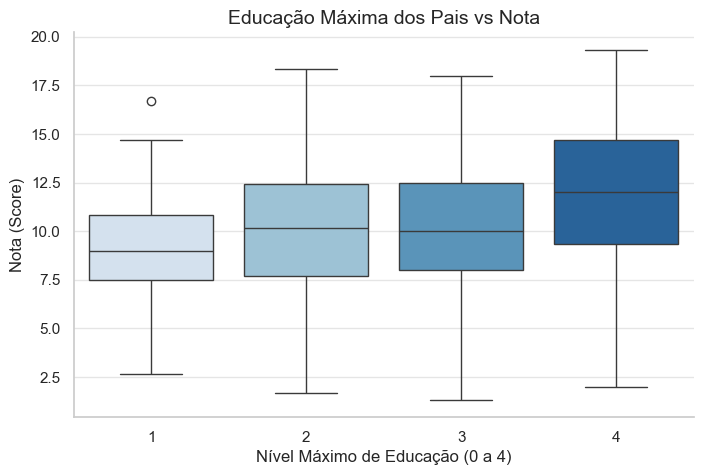

In [113]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df, 
    x='parent_max_edu', 
    y='score', 
    palette='Blues'
)
plt.title('Educação Máxima dos Pais vs Nota', fontsize=14)
plt.xlabel('Nível Máximo de Educação (0 a 4)')
plt.ylabel('Nota (Score)')
plt.show()

O gráfico demonstra uma aparente correlação direta com o score subindo a medida que tem alguem com uma escolaridade maior na família.

C:\Users\julio\AppData\Local\Temp\ipykernel_8616\1119638472.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


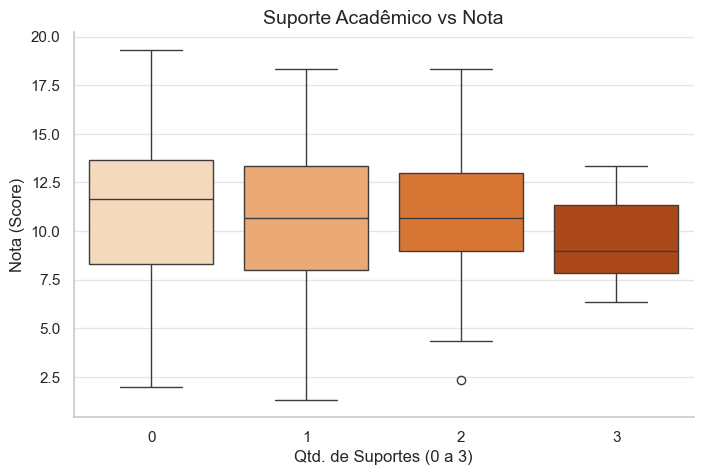

In [114]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df, 
    x='total_academic_support', 
    y='score', 
    palette='Oranges'
)
plt.title('Suporte Acadêmico vs Nota', fontsize=14)
plt.xlabel('Qtd. de Suportes (0 a 3)')
plt.ylabel('Nota (Score)')
plt.show()

O gráfico mostra uma aparente correlação inversa, contrariando a hipótese inicial, mas sendo útil. Isso significa que buscam suportes extras os alunos que possuem score mais baixo.

C:\Users\julio\AppData\Local\Temp\ipykernel_8616\4076307780.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


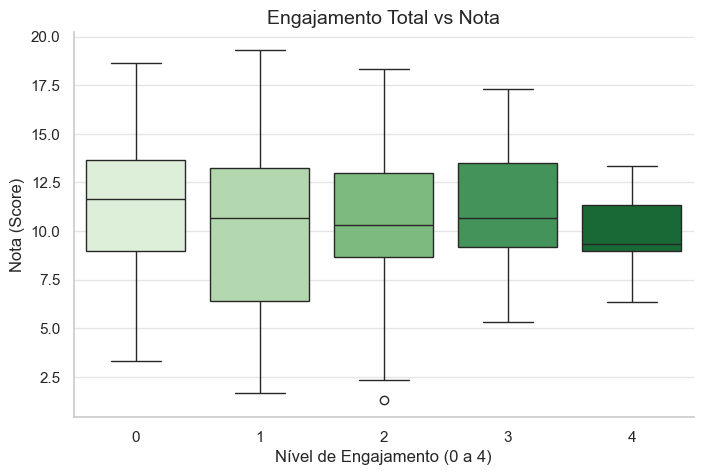

In [115]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df, 
    x='total_engagement', 
    y='score', 
    palette='Greens'
)
plt.title('Engajamento Total vs Nota', fontsize=14)
plt.xlabel('Nível de Engajamento (0 a 4)')
plt.ylabel('Nota (Score)')
plt.show() # Exibe e encerra o terceiro gráfico

Como o engajamento leva em conta o suporte acadêmico, eu esperava uma correlação inversa, mas ao unir com as atividades o gráfico mostra uma leve distribuição normal das notas, com alunos que tem alto engajamento demonstrando notas levemente mais baixas e concentradas, acredito que pode ajudar o modelo a realizar um ajuste fino nas notas usando este parametro.

## Limpeza e Pré-Processamento

In [116]:
r = ['G1', 'G2', 'G3']
df = df.drop(columns=[col for col in r if col in df.columns])

x = df.drop(columns=['score'])
y = df['score']

# Pré-processamento
feat_num = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences',
            'parent_max_edu', 'total_academic_support', 'total_engagement']
feat_cat = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 
                'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 
                'activities', 'nursery', 'higher', 'internet', 'romantic']

pre_processador = ColumnTransformer([
    ('num', StandardScaler(), feat_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), feat_cat)
])

## Modelo de Inferência e Previsão

In [117]:
modelo_ridge = Pipeline(steps=[
    ('preprocessor', pre_processador),
    ('regressor', Ridge(alpha=8.0)) # Alpha controla a força da regularização
])

scores = cross_val_score(modelo_ridge, x, y, cv=6, scoring='neg_root_mean_squared_error')
print(f"RMSE com Ridge: {-scores.mean():.4f}\n")

# Treinamento com todos os dados
modelo_ridge.fit(x, y)


# Previsão
df_test = pd.read_csv('regressao/test.csv')
df_test['parent_max_edu'] = df_test[['Medu', 'Fedu']].max(axis=1)

colunas_binarias = ['schoolsup', 'famsup', 'paid', 'activities']
for col in colunas_binarias:
  df_test[col] = df_test[col].map({'yes': 1, 'no': 0})

df_test['total_academic_support'] = (
    df_test['schoolsup'] + df_test['famsup'] + df_test['paid']
)

df_test['total_engagement'] = df_test['total_academic_support'] + df_test['activities']


previsoes_teste = modelo_ridge.predict(df_test)

submissao = pd.DataFrame({
    'ID': df_test.index,
    'Score': previsoes_teste
})


submissao.to_csv('regressao_kaggle.csv', index=False)

print(submissao.head())

RMSE com Ridge: 3.4675

   ID      Score
0   0  10.572193
1   1  11.568601
2   2  11.683730
3   3  11.032833
4   4  10.256651


c:\Users\julio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


OBS: Testei com diversos modelos, inclusive os que usam boosting, e o melhor resultado foi usando o modelo ridge. Acredito que não fiz a escolha correta com os dados na análise exploratória.

# Parte 2

## Análise Exploratória

In [118]:
df2 = pd.read_csv("classiicacao/train2.csv")
df2.head(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


Após testar diversos algoritmos de Machine Learning na Parte 1 e travar na mesma porcentagem de acertos, decidi tentar de uma outra forma e apenas limpar os dados que se sobrepoem, com o intuito de deixar o conjunto de dados limpo e fácil de se prever. Apenas encontrei 2 tipos de dados que dependem de outro, o perímetro e a área que dependem do raio, portanto apenas vou excluir esses dados do meu modelo.

## Limpeza e Pré-Processamento

In [119]:
m = df2.drop(columns=['diagnosis'])
n = df2['diagnosis']

del_feat = [
    'perimeter_mean', 'area_mean',
    'perimeter_se', 'area_se',
    'perimeter_worst', 'area_worst'
]

m_filtrado = m.drop(columns=del_feat)


m_train, m_test, n_train, n_test = train_test_split(
    m_filtrado, n, test_size=0.3, random_state=42, stratify=n
)

## Modelo de Inferência e Previsão

Precisão do modelo: 94.74%
--- Resumo dos Acertos e Erros ---
Verdadeiros Benignos: 103 (Benignos identificados corretamente)
Falsos Malignos: 4 (Benignos previstos como Malignos
Falsos Benignos: 5 (Malignos previstos como Benignos
Verdadeiros Malignos: 59 (Malignos identificados corretamente)


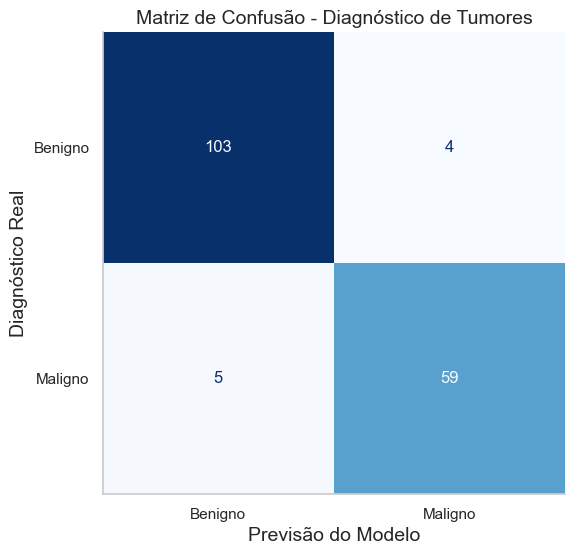

In [120]:
tree = Pipeline(steps=[
    ('classifier', DecisionTreeClassifier(
        criterion='gini',
        max_depth=4,
        min_samples_leaf=7,
        random_state=42
    ))
])


tree.fit(m_train, n_train)


previsao = tree.predict(m_test)

acuracia = accuracy_score(n_test, previsao)

print(f"Precisão do modelo: {acuracia * 100:.2f}%")

# Matriz de Confusão
matriz = confusion_matrix(n_test, previsao)

vn, fp, fn, vp = matriz.ravel()

print("--- Resumo dos Acertos e Erros ---")
print(f"Verdadeiros Benignos: {vn} (Benignos identificados corretamente)")
print(f"Falsos Malignos: {fp} (Benignos previstos como Malignos")
print(f"Falsos Benignos: {fn} (Malignos previstos como Benignos")
print(f"Verdadeiros Malignos: {vp} (Malignos identificados corretamente)")


visualizacao = ConfusionMatrixDisplay(
    confusion_matrix=matriz, 
    display_labels=['Benigno', 'Maligno']
)

plt.figure(figsize=(8, 6))
visualizacao.plot(cmap='Blues', values_format='d', ax=plt.gca(), colorbar=False)

plt.title('Matriz de Confusão - Diagnóstico de Tumores', fontsize=14)
plt.xlabel('Previsão do Modelo', fontsize=14)
plt.ylabel('Diagnóstico Real', fontsize=14)
plt.grid(False) 

plt.show()

## Previsão final

In [121]:
test2 = pd.read_csv("classiicacao/test2.csv")
test2_filtrado = test2.drop(columns=del_feat)
resp = tree.predict(test2_filtrado)

sub = pd.DataFrame({
    'id': test2_filtrado.index,
    'diagnosis': resp
})
sub['diagnosis'] = sub['diagnosis'].map({'M': 1, 'B': 0})

sub.to_csv('classiicacao_kaggle.csv', index=False)

print(sub.head(10))


   id  diagnosis
0   0          0
1   1          1
2   2          0
3   3          1
4   4          0
5   5          1
6   6          1
7   7          0
8   8          0
9   9          0
